# Workshop Tutorial: Fun with MCMC continued!

In the previous tutorial we started scratching the surface of sampling the parameter space with MCMC. In this tutorial we will focus on convergence (or lack thereof).

This interactive workshop tutorial covers some of the topics as the corresponding online tutorial(s):

* [Advanced: EMCEE Sampler](http://phoebe-project.org/docs/2.4/tutorials/emcee.ipynb)
* [Advanced: Continuing EMCEE from a Previous Run](http://phoebe-project.org/docs/2.4/tutorials/emcee_continue_from.ipynb)
* [Advanced: Resampling EMCEE from a Previous Run](http://phoebe-project.org/docs/2.4/tutorials/emcee_resampling.ipynb)
* [Advanced: Running Solvers on an External Machine](http://phoebe-project.org/docs/2.4/tutorials/export_solver.ipynb)

Let's start with the usual imports.

In [1]:
import phoebe
import matplotlib.pyplot as plt

Load the [data from the previous run](https://github.com/phoebe-project/phoebe2-workshop/raw/2025aug/data/synthetic/after_initial_sampling.bundle):

In [2]:
b = phoebe.load('./data/synthetic/after_initial_sampling.bundle')

When running the sampler, we focused on the depiction of the results; let us now take a more systematic look at the sampler output:

In [3]:
print(b['round_1'].qualifiers)

['wrap_central_values', 'fitted_twigs', 'fitted_units', 'adopt_parameters', 'adopt_distributions', 'distributions_convert', 'adopt_values', 'niters', 'nwalkers', 'samples', 'failed_samples', 'lnprobabilities', 'acceptance_fractions', 'autocorr_times', 'burnin', 'thin', 'nlags', 'lnprob_cutoff', 'progress', 'comments']


Lots to digest here. So let's get started!

`wrap_central_values`: central positions of parameters that wrap their values;

`fitted_twigs`: parameter twigs that were sampled;

`fitted_units`: the units of parameters that were sampled;

`adopt_parameters`: list of sampled parameters for which the solution should be adopted; don't choose a subset unless you have a very good reason;

`adopt_distributions`: should distributions be stored;

`distributions_convert`: should a simplified representation of the distributions be stored; we will return to this in a [later tutorial](./Tutorial_23_posteriors.ipynb);

`adopt_values`: should face values be stored;

`niters`: number of iterations used to reach the solution;

`nwalkers`: number of walkers used to reach the solution;

`samples`: MCMC samples of the shape (niters, nwalkers, npars);

`failed_samples`: MCMC samples that resulted in lnp=-inf; the return value is a dictionary where keys are failure messages and values are arrays of parameter combinations that caused the failure;

`lnprobabilities`: sampled log-probabilities of the shape (niters, nwalkers);

`acceptance_fractions`: used for convergence evaluation, provided per walker;

`autocorr_times`: autocorrelation times, used for convergence evaluation, provided per parameter;

`burnin`, `thin`, `lnprob_cutoff`: sample modifiers discussed in the previous tutorial;

`nlags`: number of autocorrelation lags to use when calculating autocorrelation;

`progress`: progress meter; useful when farming out to a cluster and checking an intermediate result;

`comments`: human-readable comments about the solution, to be used for reference.

Remember that you can always print a certain parameter to get more verbose help on its purpose; for example:

In [4]:
print(b['acceptance_fractions'])

Parameter: acceptance_fractions@round_1@solution
                       Qualifier: acceptance_fractions
                     Description: fraction of proposed steps that were accepted with shape (nwalkers)
                           Value: [0.35 0.3  0.37 0.33 0.4  0.4  0.42 0.34 0.34 0.3  0.28 0.43 0.4  0.4
 0.4  0.38]
                  Constrained by: 
                      Constrains: None
                      Related to: None



As we ran the sampler, some combinations of parameters resulted in 0 likelihood. We refer to those as failed samples and, as seen above, they are stored as part of the solution. We can easily plot those in a corner plot:

In [5]:
%matplotlib inline

(None, <Figure size 1180x1180 with 25 Axes>)

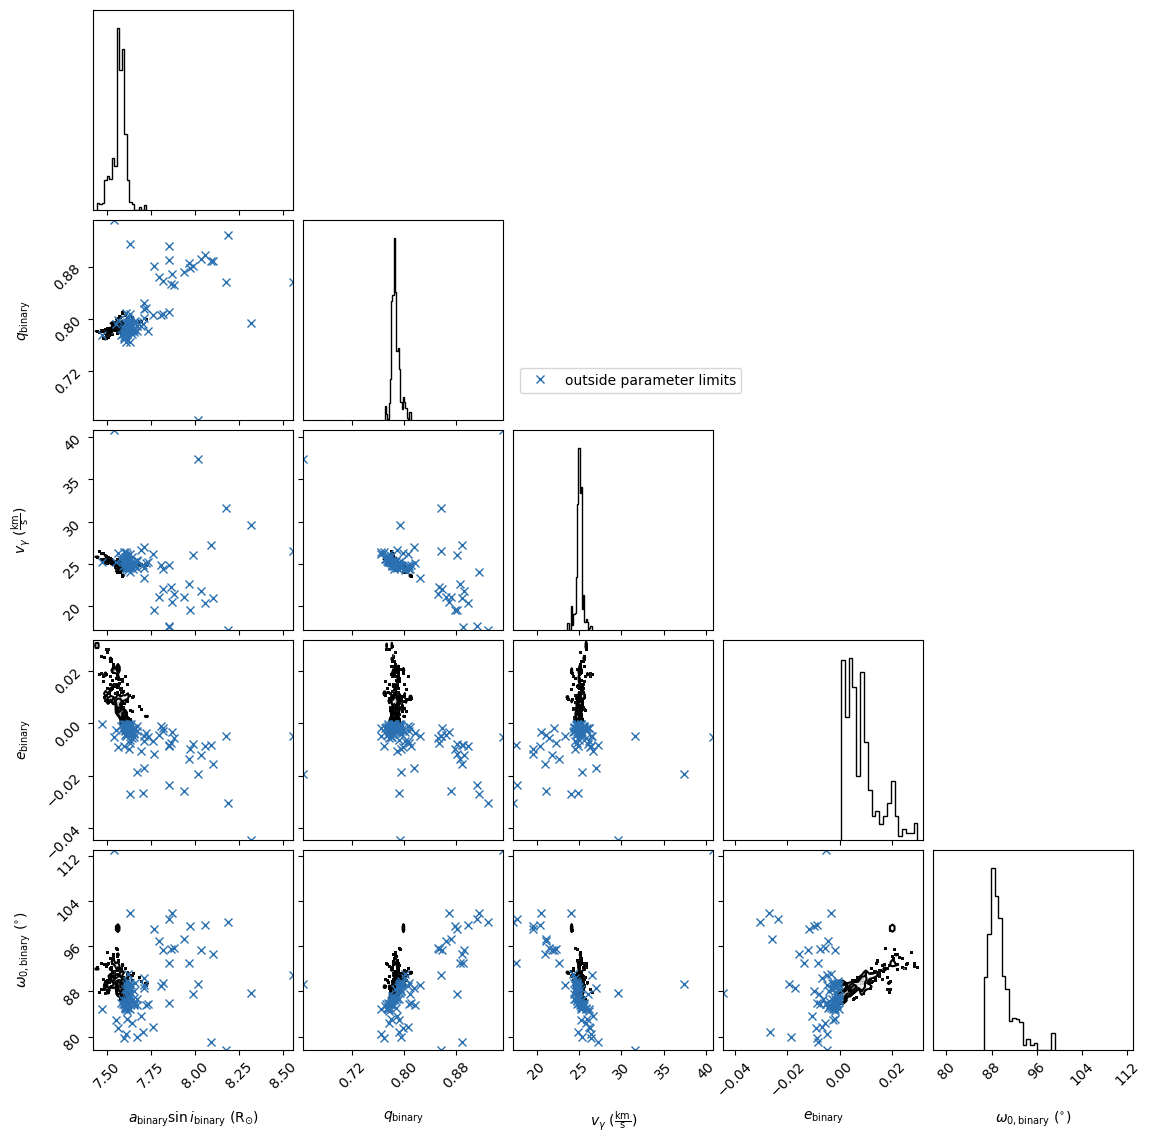

In [6]:
b.plot(solution='round_1', style='failed', burnin=50, show=True)

This is clearly a severely undersampled parameter space, but it's already evident where the failed samples lie; in this particular case, all values that fail are outside of parameter limits.

We can now compute the average RV curve from, say, 25 samples drawn from the round 1 solution:

In [7]:
b.run_compute(compute='dyn_rv', sample_from='round_1', sample_num=25, model='from_posteriors')

100%|██████████| 25/25 [00:08<00:00,  2.79it/s]


<ParameterSet: 10 parameters | components: secondary, primary>

Once computed, let's plot all 25 samples in the phase plot:

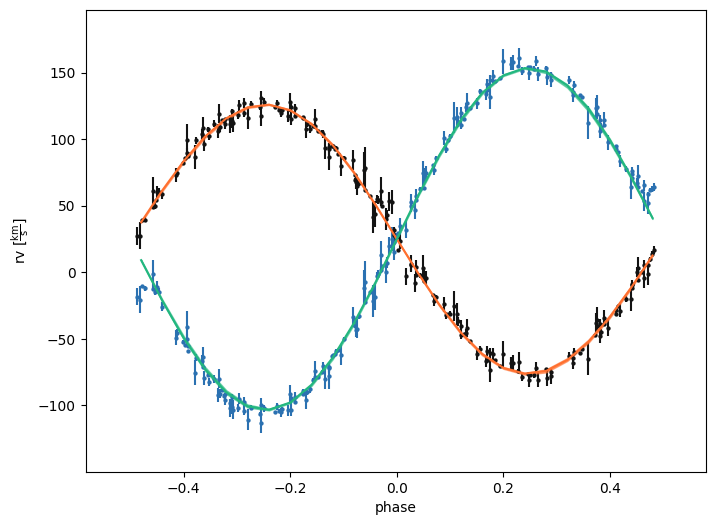

(<autofig.figure.Figure | 1 axes | 4 call(s)>,
 <Figure size 800x600 with 1 Axes>)

In [8]:
b.plot(model='from_posteriors', x='phase', s=0.005, m="o", show=True)

Happy with this? We can *inspect* the solution by running the `adopt_solution()` method with the `trial_run` argument set to `True`:

In [9]:
print(b.adopt_solution(solution='round_1', trial_run=True))

ParameterSet: 10 parameters
       asini@dists02@distribution: <distl.mvsamplesslice dimension=0 samples=[[7.65662103e+00 8.13636059e-01 2.38702645e+01 1.88369681e-02
  9.55532239e+01]
 [7.54624717e+00 7.73009196e-01 2.60223280e+01 2.08379810e-02
  8.84526830e+01]
 [7.44622513e+00 7.73189776e-01 2.64787479e+01 3.30587224e-02
  9.11620964e+01]
 ...
 [7.59201793e+00 7.84376752e-01 2.45734939e+01 2.03187267e-03
  8.82940479e+01]
 [7.56868985e+00 7.79850180e-01 2.48806234e+01 3.73716426e-03
  8.80125940e+01]
 [7.58661809e+00 7.84061115e-01 2.49010872e+01 2.63044716e-03
  8.78190485e+01]] weights=None bw_method=None unit=solRad label=asini@binary)>
           q@dists02@distribution: <distl.mvsamplesslice dimension=1 samples=[[7.65662103e+00 8.13636059e-01 2.38702645e+01 1.88369681e-02
  9.55532239e+01]
 [7.54624717e+00 7.73009196e-01 2.60223280e+01 2.08379810e-02
  8.84526830e+01]
 [7.44622513e+00 7.73189776e-01 2.64787479e+01 3.30587224e-02
  9.11620964e+01]
 ...
 [7.59201793e+00 7.8437675

The solutions that we have so far are:

In [10]:
b.solutions

['rvperiod_solution',
 'rvperiod_solution_2',
 'lcperiod_bls_solution',
 'lcperiod_ls_solution',
 'rvgeom_solution',
 'ebai_mlp_solution',
 'ebai_knn_solution',
 'lcgeom_solution',
 'nm_solution',
 'round_1']

Remember the `continue_from` parameter? That's what we want to set so that we can continue fitting starting from end point of this run.

In [11]:
print(b['continue_from@mcmc'])

Parameter: continue_from@mcmc@solver
                       Qualifier: continue_from
                     Description: continue the MCMC run from an existing emcee solution.  Chains will be appended to existing chains (so it is safe to overwrite the existing solution).  If None, will start a new run using init_from.
                           Value: None
                         Choices: None, round_1
                  Constrained by: 
                      Constrains: None
                      Related to: None



In [12]:
b['continue_from@mcmc'] = 'round_1'

The `niters` parameter will now correspond to the number of additional iterations; note that we need to specify here that we are setting `niters@solver` and not `niters@solution` (which is read-only anyway).

In [13]:
b['niters@mcmc@solver'] = 25

In [14]:
b.run_solver('mcmc', solution='round_2')

100%|██████████| 25/25 [00:47<00:00,  2.01s/it]The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 2;
tau: [10.56431819 10.719567   14.22277102 15.83746542 12.78063539]
100%|██████████| 25/25 [00:47<00:00,  1.89s/it]


<ParameterSet: 20 parameters | qualifiers: autocorr_times, lnprobabilities, burnin, fitted_twigs, adopt_parameters, progress, nwalkers, lnprob_cutoff, thin, niters, comments, distributions_convert, samples, failed_samples, acceptance_fractions, nlags, fitted_units, adopt_values, wrap_central_values, adopt_distributions>

We can now compare the results from the first sample (`round_1`) and from the second sample (`round_2`):

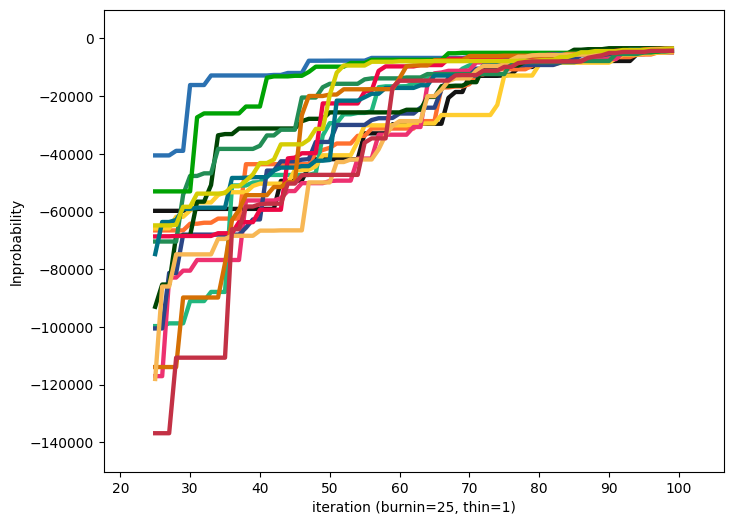

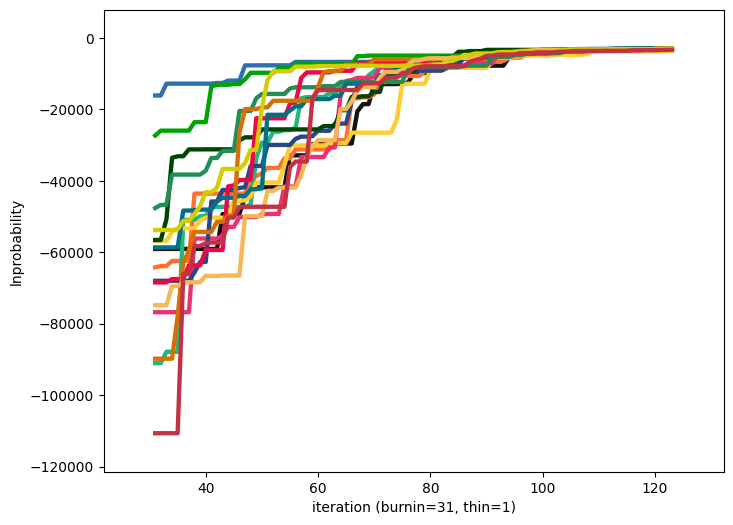

(<autofig.figure.Figure | 1 axes | 16 call(s)>,
 <Figure size 800x600 with 1 Axes>)

In [15]:
b.plot(solution='round_1', style='lnprobability', show=True)
b.plot(solution='round_2', style='lnprobability', show=True)

Several things worth mentioning here. First, note the span of the x-axis. It starts by the determined `burnin` value for each sample run (~26 for round 1 and ~31 for round 2), and it goes to the `niters` value (100 for round 1 and 125 for round 2).

How does phoebe estimate the value of `burnin`? It looks at the autocorrelation times, which emcee returns for each parameter. It then pick the longest autocorrelation time and multiplies it by the `burnin_factor`. Thus:

In [16]:
print('burnin iterations for round 1: %d' % 
      (int(max(b['value@autocorr_times@round_1'])*b['value@burnin_factor@mcmc'])))
print('burnin iterations for round 2: %d' % 
      (int(max(b['value@autocorr_times@round_2'])*b['value@burnin_factor@mcmc'])))
print('the burnin factor is: %d' % 
      (b['value@burnin_factor@mcmc']))

burnin iterations for round 1: 25
burnin iterations for round 2: 31
the burnin factor is: 2


The value of log-probability, as well as the fact that it's still rising, hints that the solution has not yet converged, so we'd need to run a longer chain. As running 25 iterations locally took 3 minutes, we would ideally offload this computation to a computer cluster.

If we were to offload this computation to the HPC, it would make sense to increase the number of walkers from the current 16 to, say, 24 or 48, so that the sampler can traverse the parameter space more efficiently. The parameter `nwalkers` is in the solver parameter set:

In [17]:
print(b['mcmc@solver'])

ParameterSet: 11 parameters
             comments@mcmc@solver: 
           use_server@mcmc@solver: compute
              compute@mcmc@solver: dyn_rv
        continue_from@mcmc@solver: round_1
   continue_from_iter@mcmc@solver: -1
               priors@mcmc@solver: []
               niters@mcmc@solver: 25
        burnin_factor@mcmc@solver: 2.0
          thin_factor@mcmc@solver: 0.0
         nlags_factor@mcmc@solver: 3.0
   progress_every_niters@mcmc@...: 0


Wait, it disappeared? No, it hasn't disappeared, it is hidden because we have `continue_from` set to the previous run, from which any new run will inherit all sampling parameters. Thus, we first need to set `continue_from` to none:

In [18]:
b['continue_from@mcmc@solver'] = 'None'
print(b['mcmc@solver'])

ParameterSet: 15 parameters
             comments@mcmc@solver: 
           use_server@mcmc@solver: compute
              compute@mcmc@solver: dyn_rv
        continue_from@mcmc@solver: None
            init_from@mcmc@solver: ['ndg']
    init_from_combine@mcmc@solver: first
   init_from_requires@mcmc@solver: ['limits', 'priors']
               priors@mcmc@solver: []
             nwalkers@mcmc@solver: 16
               niters@mcmc@solver: 25
        burnin_factor@mcmc@solver: 2.0
          thin_factor@mcmc@solver: 0.0
         nlags_factor@mcmc@solver: 3.0
   progress_every_niters@mcmc@...: 0
        expose_failed@mcmc@solver: True


There it is! Now we can change it!

In [19]:
b['nwalkers@mcmc@solver'] = 24

But now how do we continue from the previous run? We cannot continue as before because we have changed the sampler properties (specifically, the number of walkers); instead, we need to *resample* from the last run. We do that by using the `init_from` parameter. In order to have something to initialize from, we first need to adopt parameters from the last run. We will call the distributions "ndg_2":

In [20]:
b.adopt_solution(solution='round_2',
                 adopt_values=False,
                 adopt_distributions=True,
                 distributions_convert='mvsamples',
                 distribution='ndg_2')

<ParameterSet: 5 parameters | qualifiers: ecc, asini, q, per0, vgamma>

Now we have a new distribution:

In [21]:
b.distributions

['ndg', 'ndg_2']

We can use this new distribution to set the `init_from` parameter. The sampler will then use `ndg_2` to get a new sample for all initial values and continue from there.

In [22]:
b['init_from@mcmc@solver'] = 'ndg_2'

We're now ready to run the sampler! Below is the code to do this on a cluster. For now, however, we will load the precomputed results so that we can continue through the tutorial, but we'll talk about the setup to make sure you're comfortable:

In [23]:
#b.add_server(
#    kind='remoteslurm',
#    server='terra',
#    crimpl_name='terra',
#    conda_env='phoebe_workshop',
#    nprocs=24,
#    walltime=2,
#    overwrite=True
#)

In [24]:
#b.run_solver('mcmc', solution='round_3', use_server='terra', nprocs=24, progress_every_niters=20, niters=500, detach=True)

In [25]:
#b.save('./data/synthetic/after_terra.bundle')

In [26]:
#b.get_job_status(solution='round_3')

In [27]:
#b.load_job_progress(solution='round_3')

In [28]:
#print(b.get_solution('round_3'))

In [29]:
#b.save('./data/synthetic/after_terra.bundle')

In [30]:
b = phoebe.load('./data/synthetic/after_terra.bundle')

Now we can explore the solution and compare it to what we had before.

Log-probability plot:

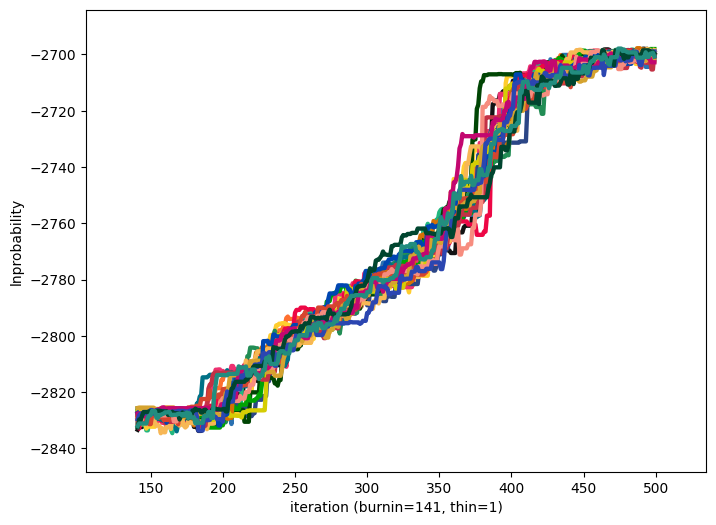

(<autofig.figure.Figure | 1 axes | 24 call(s)>,
 <Figure size 800x600 with 1 Axes>)

In [31]:
b.plot(solution='round_3', style='lnprobability', show=True)

Imagine that one or a few of our walkers landed in a local minimum and have a log probability well below the rest of the walkers. We can specify a log probability cutoff so that these walkers don't affect our resulting distributions. Warning: Do not abuse this - if many walkers are getting stuck, it is likely due to your parameterization. Consider how your parameterize your system (i.e. esinw and ecosw instead of e and w).

In [32]:
b['lnprob_cutoff@round_3'] = - 2800

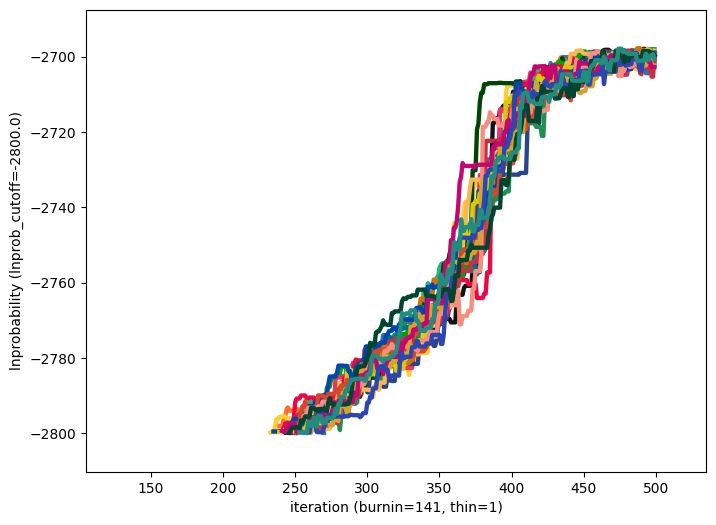

(<autofig.figure.Figure | 1 axes | 24 call(s)>,
 <Figure size 800x600 with 1 Axes>)

In [33]:
b.plot(solution='round_3', style='lnprobability', show=True)

Corner plot:

(None, <Figure size 1180x1180 with 25 Axes>)

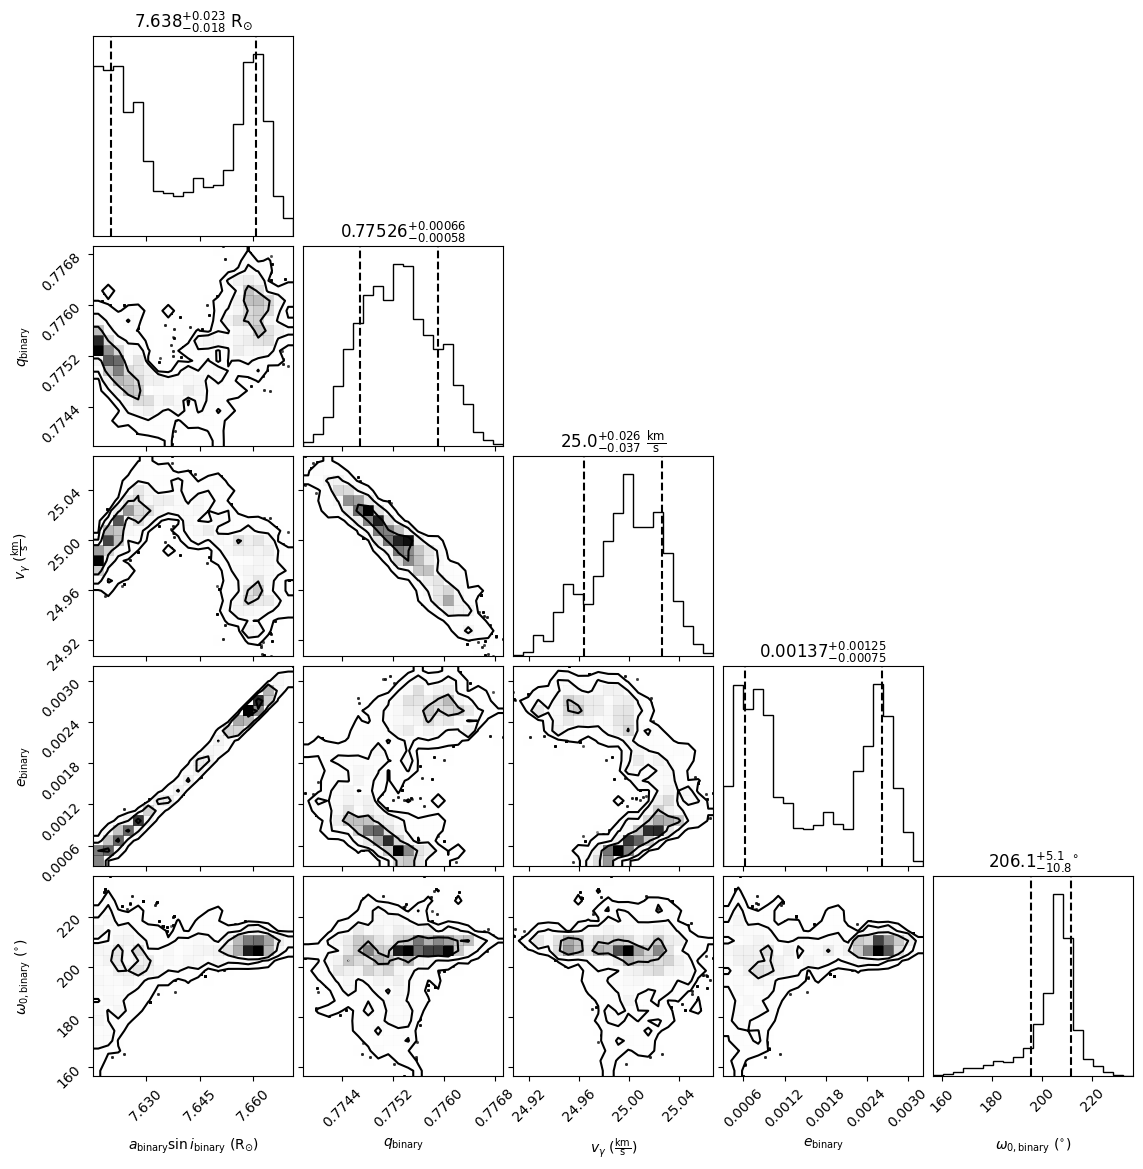

In [34]:
b.plot(solution='round_3', style='corner', show=True)

In [35]:
print(b['burnin@round_3'])

Parameter: burnin@round_3@solution
                       Qualifier: burnin
                     Description: burnin to use when adopting/plotting the solution
                           Value: 141
                  Constrained by: 
                      Constrains: None
                      Related to: None



(None, <Figure size 1180x1180 with 25 Axes>)

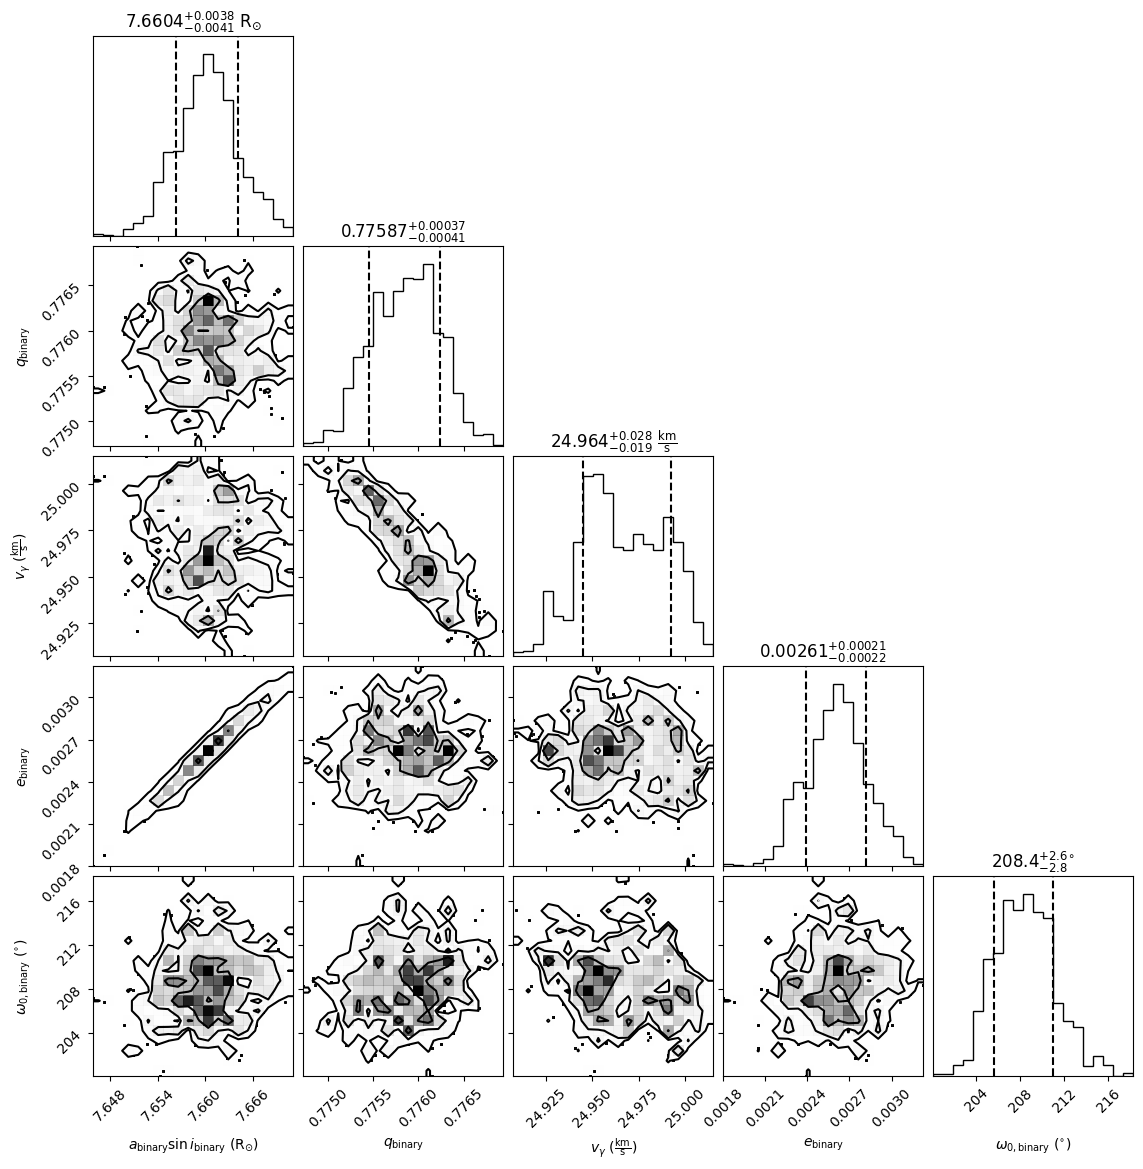

In [36]:
b.plot(solution='round_3', style='corner', burnin=420, show=True)

And finally the trace plot:

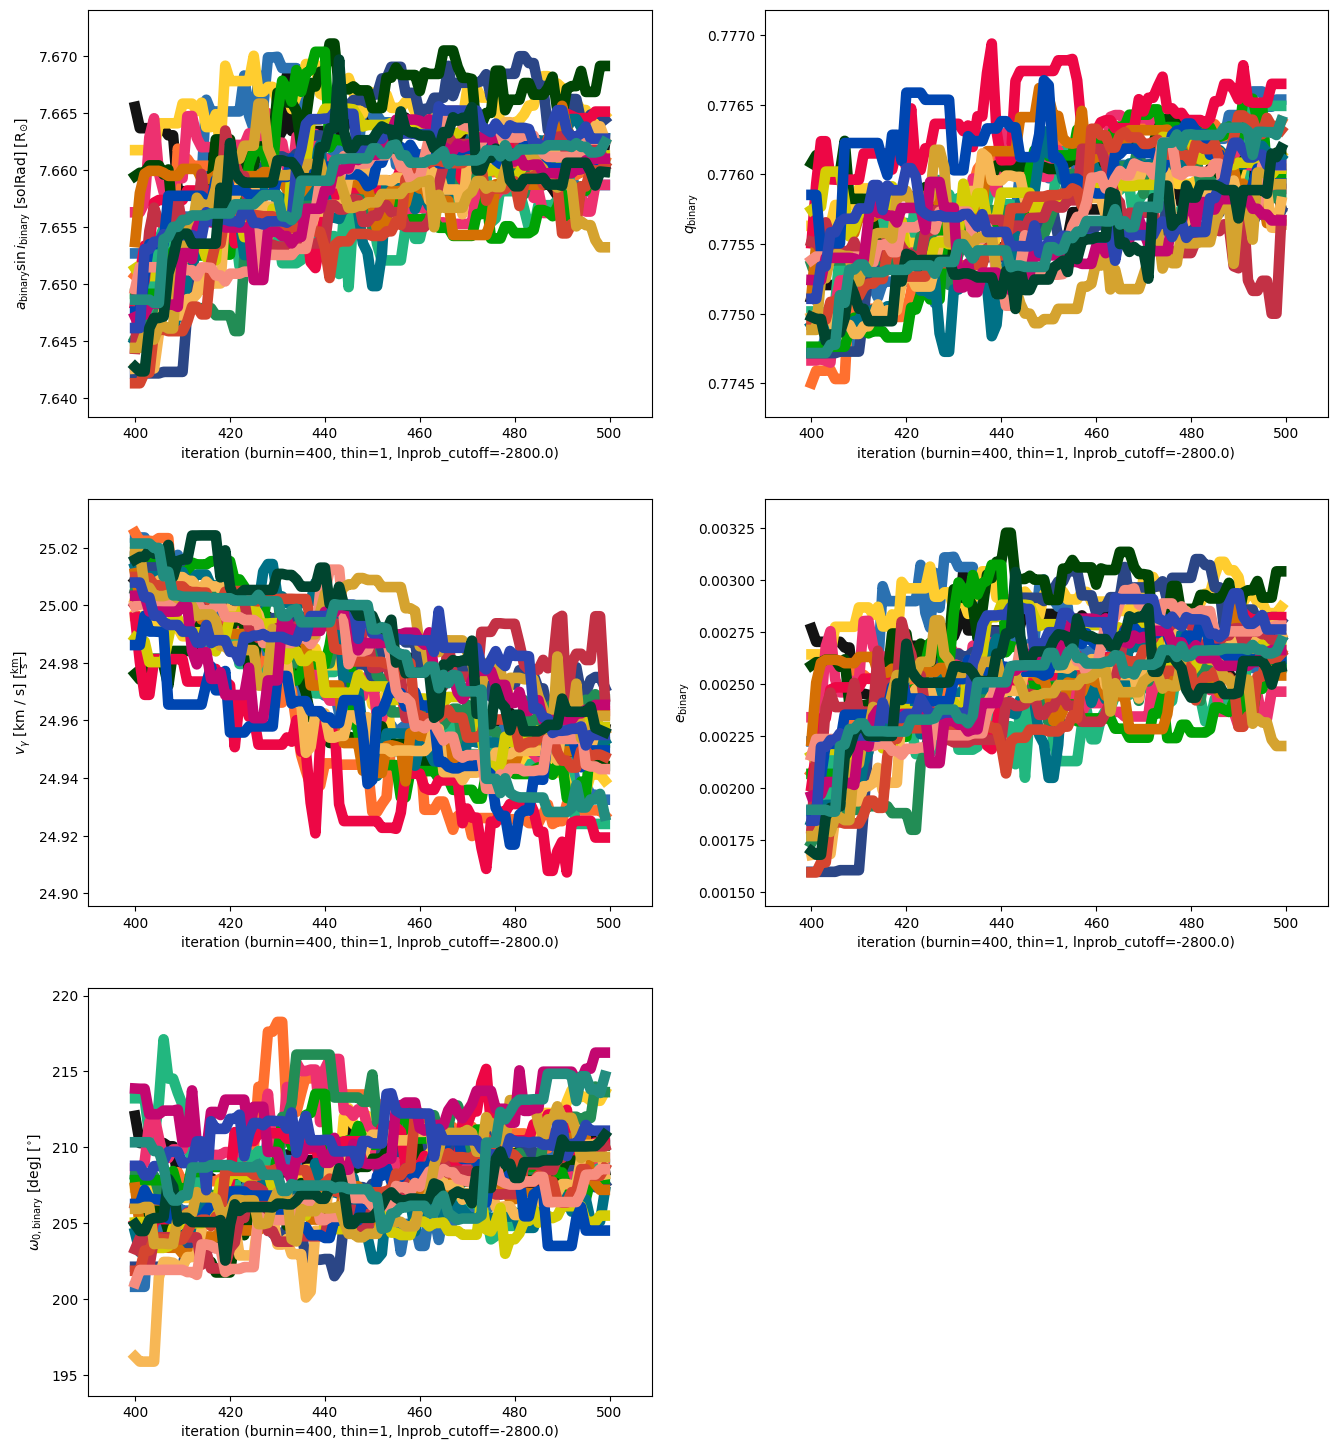

(<autofig.figure.Figure | 5 axes | 120 call(s)>,
 <Figure size 1600x1800 with 5 Axes>)

In [37]:
b.plot(solution='round_3', style='trace', burnin=400, show=True)

So how do we know when to stop? Is it converged yet? We will explore that in our [next tutorial](./Tutorial_19_convergence.ipynb).

# Exercises

**Exercise 1**: increase the number of walkers to 48 and run an additional 25 iterations. Compare the results from above to the results you obtained. What conclusions can you draw from the comparison? (Hint: you'll need to start from distributions)

**Exercise 2**: disable RVs and enable the light curve. Start from the optimized parameter set from the Nelder & Mead run and build a starting distribution around it. Use 5 parameters: inclination, temperature ratio, primary and secondary equivalent radii, and passband luminosity. Don't run any samples yet -- we will defer this to self-study exercises.